# Redes Neurais de Base Radial (RBF) - Atividade 07

Aproximação funcional para sistema de injeção eletrônica utilizando redes neurais RBF.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Carregamento de Dados

In [2]:
X_train = np.array([[0.9532, 0.6949, 0.4451], [0.7408, 0.5351, 0.2732], [0.5497, 0.6319, 0.8382], [0.7954, 0.8346, 0.0449], [0.6843, 0.3737, 0.1562], [0.7072, 0.1721, 0.3812], [0.1427, 0.048, 0.6267], [0.8799, 0.7998, 0.3972], [0.1185, 0.5084, 0.8376], [0.1516, 0.9824, 0.0827], [0.57, 0.5111, 0.2418], [0.6365, 0.5562, 0.4965], [0.4868, 0.6223, 0.7462], [0.6796, 0.4117, 0.337], [0.4145, 0.5797, 0.8599], [0.3408, 0.5115, 0.0783], [0.3567, 0.2967, 0.6037], [0.2575, 0.5358, 0.4028], [0.8146, 0.6378, 0.5837], [0.3866, 0.839, 0.0232], [0.2026, 0.33, 0.3054], [0.282, 0.5409, 0.7256], [0.0271, 0.7788, 0.7445], [0.3385, 0.0476, 0.5941], [0.5716, 0.2958, 0.5477], [0.8174, 0.8422, 0.3229], [0.4094, 0.1726, 0.7803], [0.9323, 0.0229, 0.4797], [0.6027, 0.1468, 0.3759], [0.1261, 0.6181, 0.4927], [0.2907, 0.7245, 0.5165], [0.1203, 0.326, 0.5419], [0.1224, 0.4662, 0.2146], [0.0068, 0.0545, 0.0861], [0.1325, 0.2082, 0.4934], [0.6793, 0.6774, 1.0], [0.2636, 0.9885, 0.2175], [0.695, 1.0, 0.4321], [0.8176, 0.0358, 0.2506], [0.035, 0.3653, 0.7801], [0.0036, 0.194, 0.3274], [0.6937, 0.6685, 0.5075], [0.967, 0.3031, 0.7127], [0.265, 0.0161, 0.5947], [0.2404, 0.5411, 0.8754], [0.0, 0.7763, 0.8735], [0.5849, 0.6019, 0.4376], [0.6553, 0.2609, 0.1188], [0.4395, 0.0501, 0.9761], [0.0108, 0.3538, 0.181], [0.8886, 0.0288, 0.2604], [0.9359, 0.0366, 0.9514], [0.9008, 0.7264, 0.9184], [0.3974, 0.5275, 0.6457], [0.0173, 0.9548, 0.4289], [0.0023, 0.9659, 0.3182], [0.2108, 0.491, 0.5432], [0.6112, 0.907, 0.6286], [0.1366, 0.6357, 0.6967], [0.8675, 0.5571, 0.1849], [0.201, 0.9573, 0.6791], [0.8621, 0.7353, 0.2742], [0.5693, 0.0242, 0.9293], [0.8914, 0.9144, 0.2641], [0.0682, 0.9624, 0.4211], [0.8439, 0.4631, 0.6345], [0.0061, 0.0802, 0.8621], [0.6112, 0.6014, 0.5254], [0.3644, 0.2948, 0.3937], [0.2212, 0.4664, 0.3821], [0.003, 0.7585, 0.8928], [0.2014, 0.6326, 0.9782], [0.2401, 0.6964, 0.0751], [0.7644, 0.5964, 0.0407], [0.4039, 0.0645, 0.4629], [0.7881, 0.9833, 0.3038], [0.6441, 0.2097, 0.5847], [0.7137, 0.067, 0.2359], [0.2435, 0.0794, 0.5551], [0.0803, 0.3799, 0.602], [0.4277, 0.9555, 0.0], [0.2752, 0.8414, 0.2797], [0.1908, 0.8046, 0.5402], [0.0259, 0.7634, 0.2889], [0.7616, 0.4698, 0.5337], [0.6937, 0.3967, 0.6055], [0.1871, 0.7682, 0.9697], [0.3395, 0.0022, 0.0087], [0.2591, 0.0582, 0.3978], [0.3216, 0.542, 0.0677], [0.7849, 0.9981, 0.4449], [0.4241, 0.185, 0.9066], [0.2524, 0.7688, 0.9523], [0.8312, 0.0961, 0.2129], [0.3332, 0.9303, 0.2475], [0.3621, 0.5295, 0.2521], [0.9763, 0.1102, 0.6227], [0.3625, 0.1592, 0.9981], [0.2942, 0.1625, 0.2745], [0.8597, 0.3284, 0.6932], [0.9259, 0.096, 0.1645], [0.818, 0.0023, 0.1439], [0.9295, 0.3275, 0.7536], [0.8606, 0.6779, 0.0033], [0.8429, 0.1704, 0.5251], [0.2435, 0.2163, 0.7625], [0.0838, 0.5472, 0.3758], [0.9612, 0.6898, 0.663], [0.9281, 0.8356, 0.5285], [0.0303, 0.9191, 0.7233], [0.1009, 0.419, 0.0826], [0.8313, 0.7566, 0.6192], [0.9293, 0.8319, 0.9664], [0.7071, 0.7704, 0.8328], [0.1712, 0.0545, 0.5033], [0.7268, 0.144, 0.9753], [0.3371, 0.7819, 0.0959], [0.0609, 0.1702, 0.4306], [0.2888, 0.6593, 0.4078], [0.9931, 0.6727, 0.3139], [0.5899, 0.9408, 0.0369], [0.5515, 0.1364, 0.2894], [0.9123, 0.0, 0.1106], [0.7858, 0.5115, 0.0916], [0.7683, 0.0067, 0.5546], [0.2858, 0.9688, 0.2262], [1.0, 0.1653, 0.7103], [0.6462, 0.6761, 0.834], [0.7931, 0.8993, 0.9028], [0.2007, 0.1163, 0.3431], [0.3694, 0.2212, 0.1233], [0.7841, 0.0778, 0.9012], [0.2306, 0.033, 0.0293], [0.2706, 0.3222, 0.9996], [0.138, 0.5881, 0.2367], [0.8477, 0.6378, 0.4623], [0.6282, 0.1404, 0.8474], [0.6345, 0.5165, 0.7139], [0.9677, 0.7895, 0.9467], [0.5861, 0.6693, 0.3818], [0.2453, 0.5888, 0.1559], [0.0339, 0.4669, 0.1526], [0.6057, 0.9901, 0.5141], [0.1174, 0.5436, 0.3657], [0.008, 0.8988, 0.4201], [0.5915, 0.5588, 0.3055], [0.3667, 0.3228, 0.6952], [0.9955, 0.8897, 0.6175], [0.8359, 0.4145, 0.5016], [0.2204, 0.1785, 0.4607]])
D_train = np.array([0.8426, 0.6949, 0.8521, 0.6676, 0.5625, 0.5772, 0.378, 0.8399, 0.6211, 0.4627, 0.6258, 0.7693, 0.8116, 0.6622, 0.7878, 0.4559, 0.5969, 0.5777, 0.8628, 0.5316, 0.4261, 0.6939, 0.6335, 0.4625, 0.6619, 0.8068, 0.6015, 0.5731, 0.5342, 0.5739, 0.6911, 0.4768, 0.4007, 0.0851, 0.4105, 0.9141, 0.5847, 0.8404, 0.4707, 0.5117, 0.2697, 0.822, 0.7836, 0.4125, 0.698, 0.6388, 0.7464, 0.4851, 0.5712, 0.28, 0.4802, 0.6826, 0.9602, 0.7215, 0.5527, 0.4986, 0.5913, 0.8803, 0.6459, 0.6805, 0.7283, 0.7718, 0.6033, 0.7966, 0.5764, 0.8226, 0.3711, 0.7868, 0.524, 0.526, 0.6388, 0.7143, 0.4637, 0.6055, 0.4547, 0.8049, 0.6545, 0.4602, 0.4223, 0.4991, 0.5477, 0.6079, 0.6665, 0.4738, 0.7809, 0.7595, 0.7397, 0.1836, 0.3604, 0.4526, 0.8641, 0.6298, 0.7711, 0.4857, 0.6287, 0.5571, 0.6667, 0.5948, 0.3759, 0.7829, 0.4716, 0.4018, 0.8016, 0.6242, 0.6563, 0.5449, 0.4835, 0.9128, 0.8991, 0.6491, 0.3055, 0.9047, 0.984, 0.9298, 0.3561, 0.7096, 0.5377, 0.331, 0.6328, 0.7829, 0.6245, 0.4745, 0.3944, 0.6066, 0.5708, 0.5988, 0.7172, 0.8933, 0.9728, 0.3385, 0.3658, 0.6832, 0.159, 0.631, 0.4622, 0.8254, 0.6733, 0.8191, 0.9782, 0.7433, 0.4765, 0.325, 0.8466, 0.4953, 0.5404, 0.6787, 0.6376, 0.936, 0.7597, 0.4276])

X_test = np.array([[0.5102, 0.7464, 0.086], [0.8401, 0.449, 0.2719], [0.1283, 0.1882, 0.7253], [0.2299, 0.1524, 0.7353], [0.3209, 0.6229, 0.5233], [0.8203, 0.0682, 0.426], [0.3471, 0.8889, 0.1564], [0.5762, 0.8292, 0.4116], [0.9053, 0.6245, 0.5264], [0.8149, 0.0396, 0.6227], [0.1016, 0.6382, 0.3173], [0.9108, 0.2139, 0.4641], [0.2245, 0.0971, 0.6136], [0.6423, 0.3229, 0.8567], [0.5252, 0.6529, 0.5729]])
D_test = np.array([0.5965, 0.679, 0.4662, 0.5012, 0.681, 0.5643, 0.5875, 0.7853, 0.8506, 0.6165, 0.4957, 0.6625, 0.4402, 0.7663, 0.7893])

### Função da RBF (Treinamento e Validação)

In [3]:
def gaussian(X, centers, variances):
    H = np.zeros((X.shape[0], len(centers)))
    for i in range(len(centers)):
        H[:, i] = np.exp(-np.linalg.norm(X - centers[i], axis=1)**2 / (2 * variances[i]))
    return H

### Gráficos Gerados

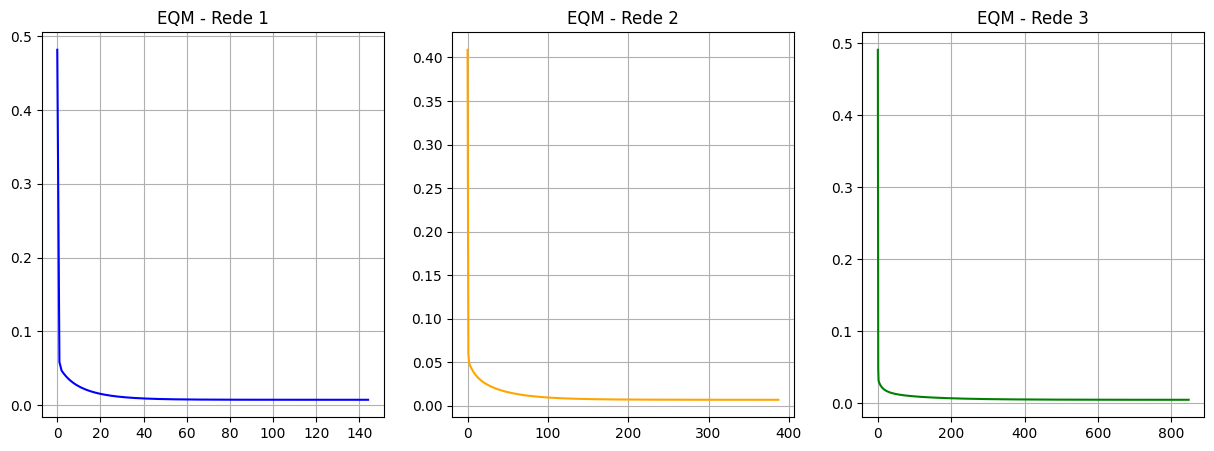

In [4]:
eqm_r1 = [np.float64(0.48191318249990484), np.float64(0.058424300910192385), np.float64(0.046752641582698984), np.float64(0.04269888216735892), np.float64(0.03918684072233318), np.float64(0.03611163126903358), np.float64(0.03341387860762351), np.float64(0.031035209463915078), np.float64(0.02892673306598656), np.float64(0.027048453617971552), np.float64(0.025367620418913238), np.float64(0.023857275712419055), np.float64(0.022495094220481668), np.float64(0.021262467845050637), np.float64(0.02014378389485287), np.float64(0.019125854745914054), np.float64(0.018197465980899726), np.float64(0.017349017347817474), np.float64(0.016572236557436015), np.float64(0.0158599503447699), np.float64(0.015205900639610121), np.float64(0.014604596347661036), np.float64(0.01405119330977793), np.float64(0.013541396615105755), np.float64(0.013071380697303734), np.float64(0.012637723620891505), np.float64(0.012237352728489567), np.float64(0.011867499416921463), np.float64(0.01152566127767422), np.float64(0.01120957020369344), np.float64(0.01091716535214385), np.float64(0.010646570078872734), np.float64(0.010396072138313124), np.float64(0.01016410658292526), np.float64(0.009949240907155397), np.float64(0.009750162068655399), np.float64(0.009565665089123154), np.float64(0.009394642992475362), np.float64(0.009236077882187043), np.float64(0.00908903299490389), np.float64(0.008952645595717046), np.float64(0.00882612060324575), np.float64(0.008708724851049883), np.float64(0.008599781906792699), np.float64(0.008498667382704495), np.float64(0.00840480468082012), np.float64(0.008317661124618063), np.float64(0.008236744435426262), np.float64(0.008161599517555308), np.float64(0.008091805520793065), np.float64(0.008026973152819993), np.float64(0.007966742217420459), np.float64(0.007910779357182894), np.float64(0.007858775981789521), np.float64(0.0078104463650660975), np.float64(0.007765525895750462), np.float64(0.007723769468493052), np.float64(0.007684950002959524), np.float64(0.007648857080096853), np.float64(0.007615295685674279), np.float64(0.0075840850521400405), np.float64(0.007555057590661235), np.float64(0.007528057905951077), np.float64(0.0075029418871476955), np.float64(0.0074795758686007265), np.float64(0.007457835854955184), np.float64(0.007437606805403036), np.float64(0.007418781972408248), np.float64(0.0074012622906051255), np.float64(0.007384955811928054), np.float64(0.007369777183356022), np.float64(0.007355647163951978), np.float64(0.007342492178147231), np.float64(0.007330243902468011), np.float64(0.007318838883126763), np.float64(0.0073082181821069745), np.float64(0.007298327049559381), np.float64(0.0072891146205000985), np.float64(0.007280533633960259), np.float64(0.007272540172881885), np.float64(0.007265093423188557), np.float64(0.007258155450582026), np.float64(0.0072516909937286435), np.float64(0.007245667272603174), np.float64(0.007240053810852712), np.float64(0.007234822271131327), np.float64(0.007229946302436475), np.float64(0.007225401398552725), np.float64(0.007221164766776605), np.float64(0.007217215206159538), np.float64(0.007213532994563658), np.float64(0.0072100997838791545), np.float64(0.0072068985028008), np.float64(0.007203913266607049), np.float64(0.0072011292934269396), np.float64(0.0071985328265188305), np.float64(0.007196111062120655), np.float64(0.007193852082464409), np.float64(0.007191744793578006), np.float64(0.007189778867525781), np.float64(0.007187944688764831), np.float64(0.007186233304318394), np.float64(0.007184636377489646), np.float64(0.007183146144859728), np.float64(0.007181755376332741), np.float64(0.007180457338007992), np.float64(0.007179245757675889), np.float64(0.007178114792748847), np.float64(0.007177059000452427), np.float64(0.007176073310114717), np.float64(0.007175152997403759), np.float64(0.007174293660373866), np.float64(0.007173491197191671), np.float64(0.007172741785422341), np.float64(0.0071720418627648184), np.float64(0.007171388109133251), np.float64(0.007170777429989003), np.float64(0.007170206940834696), np.float64(0.007169673952788013), np.float64(0.007169175959159008), np.float64(0.00716871062296004), np.float64(0.007168275765282653), np.float64(0.007167869354480321), np.float64(0.007167489496100451), np.float64(0.007167134423512992), np.float64(0.007166802489186823), np.float64(0.0071664921565685194), np.float64(0.007166201992521352), np.float64(0.007165930660285397), np.float64(0.007165676912922321), np.float64(0.007165439587211137), np.float64(0.007165217597963379), np.float64(0.007165009932728692), np.float64(0.007164815646863543), np.float64(0.007164633858937946), np.float64(0.007164463746456694), np.float64(0.00716430454187338), np.float64(0.007164155528876845), np.float64(0.007164016038931301), np.float64(0.0071638854480525925), np.float64(0.0071637631738042246), np.float64(0.007163648672498128), np.float64(0.007163541436585955), np.float64(0.007163440992227841), np.float64(0.007163346897026443)]
eqm_r2 = [np.float64(0.4088368698825408), np.float64(0.05944873618131531), np.float64(0.04870797882051948), np.float64(0.04658990081795373), np.float64(0.044586103582411454), np.float64(0.04271388279203461), np.float64(0.04100222682139588), np.float64(0.03943949142656646), np.float64(0.03800828442880743), np.float64(0.03669247241699251), np.float64(0.03547806752984068), np.float64(0.034353072737593235), np.float64(0.033307198392879135), np.float64(0.03233160017836879), np.float64(0.031418656538623496), np.float64(0.03056178226580555), np.float64(0.029755272450583643), np.float64(0.028994171584240516), np.float64(0.028274163491713047), np.float64(0.02759147856226073), np.float64(0.026942815386305316), np.float64(0.026325274424431843), np.float64(0.02573630175225652), np.float64(0.025173641263411442), np.float64(0.024635293988469666), np.float64(0.024119483412902386), np.float64(0.023624625862043454), np.float64(0.023149305173343813), np.float64(0.022692251002103408), np.float64(0.022252320211283073), np.float64(0.021828480882843133), np.float64(0.02141979856048288), np.float64(0.021025424394204892), np.float64(0.020644584907862466), np.float64(0.020276573153444798), np.float64(0.01992074105168356), np.float64(0.019576492748753567), np.float64(0.01924327884431474), np.float64(0.01892059136767018), np.float64(0.0186079593970307), np.float64(0.018304945232307), np.float64(0.018011141044937833), np.float64(0.01772616593937308), np.float64(0.0174496633702727), np.float64(0.01718129886751295), np.float64(0.016920758027929635), np.float64(0.016667744738552967), np.float64(0.016421979601057915), np.float64(0.01618319853139371), np.float64(0.01595115151217878), np.float64(0.015725601478543568), np.float64(0.015506323320753477), np.float64(0.015293102989212468), np.float64(0.015085736689392431), np.float64(0.014884030155901062), np.float64(0.014687797996332895), np.float64(0.014496863096778355), np.float64(0.014311056081924341), np.float64(0.014130214823590736), np.float64(0.013954183992332657), np.float64(0.013782814647416047), np.float64(0.013615963861059024), np.float64(0.013453494373337977), np.float64(0.013295274274595306), np.float64(0.013141176712565544), np.float64(0.012991079621766353), np.float64(0.012844865472987571), np.float64(0.012702421040960655), np.float64(0.012563637188508595), np.float64(0.012428408665665849), np.float64(0.012296633922424161), np.float64(0.012168214933905082), np.float64(0.012043057036887959), np.float64(0.011921068776733533), np.float64(0.011802161763842587), np.float64(0.011686250538875509), np.float64(0.011573252446035649), np.float64(0.01146308751378715), np.float64(0.011355678342438497), np.float64(0.011250949998076062), np.float64(0.011148829912379936), np.float64(0.011049247787896623), np.float64(0.010952135508381117), np.float64(0.010857427053854769), np.float64(0.010765058420055875), np.float64(0.010674967541987096), np.float64(0.010587094221288578), np.float64(0.01050138005718766), np.float64(0.01041776838079618), np.float64(0.010336204192544381), np.float64(0.01025663410255699), np.float64(0.010179006273791757), np.float64(0.010103270367774446), np.float64(0.010029377492776428), np.float64(0.00995728015429253), np.float64(0.009886932207686695), np.float64(0.009818288812882787), np.float64(0.009751306390986213), np.float64(0.00968594258273005), np.float64(0.009622156208646527), np.float64(0.009559907230871538), np.float64(0.00949915671649574), np.float64(0.00943986680238173), np.float64(0.009382000661371763), np.float64(0.009325522469815469), np.float64(0.009270397376351412), np.float64(0.009216591471880408), np.float64(0.00916407176067246), np.float64(0.00911280613255261), np.float64(0.009062763336114336), np.float64(0.009013912952912154), np.float64(0.008966225372588022), np.float64(0.008919671768888558), np.float64(0.008874224076532891), np.float64(0.00882985496889284), np.float64(0.008786537836449693), np.float64(0.008744246765993427), np.float64(0.008702956520532497), np.float64(0.008662642519883634), np.float64(0.008623280821913078), np.float64(0.008584848104402057), np.float64(0.008547321647510634), np.float64(0.008510679316815647), np.float64(0.008474899546899416), np.float64(0.008439961325467368), np.float64(0.008405844177973566), np.float64(0.008372528152734407), np.float64(0.008339993806511488), np.float64(0.008308222190545772), np.float64(0.008277194837025941), np.float64(0.008246893745974584), np.float64(0.008217301372536805), np.float64(0.008188400614656356), np.float64(0.00816017480112528), np.float64(0.008132607679993426), np.float64(0.008105683407325169), np.float64(0.008079386536290867), np.float64(0.008053702006581431), np.float64(0.00802861513413462), np.float64(0.008004111601162428), np.float64(0.007980177446469243), np.float64(0.007956799056050814), np.float64(0.007933963153964708), np.float64(0.007911656793463069), np.float64(0.007889867348379086), np.float64(0.007868582504758746), np.float64(0.007847790252729938), np.float64(0.00782747887860115), np.float64(0.00780763695718242), np.float64(0.00778825334432141), np.float64(0.0077693171696477815), np.float64(0.007750817829519351), np.float64(0.007732744980163588), np.float64(0.007715088531008509), np.float64(0.00769783863819704), np.float64(0.007680985698279193), np.float64(0.007664520342076661), np.float64(0.007648433428714547), np.float64(0.007632716039815233), np.float64(0.007617359473849456), np.float64(0.0076023552406398786), np.float64(0.007587695056012726), np.float64(0.007573370836592961), np.float64(0.007559374694738864), np.float64(0.007545698933611898), np.float64(0.007532336042377912), np.float64(0.007519278691535854), np.float64(0.007506519728370356), np.float64(0.007494052172524531), np.float64(0.007481869211689639), np.float64(0.007469964197408177), np.float64(0.007458330640987289), np.float64(0.007446962209519216), np.float64(0.007435852722005907), np.float64(0.007424996145584775), np.float64(0.007414386591852763), np.float64(0.007404018313286028), np.float64(0.007393885699752533), np.float64(0.007383983275114958), np.float64(0.007374305693921476), np.float64(0.007364847738181929), np.float64(0.0073556043142270836), np.float64(0.007346570449648658), np.float64(0.007337741290317953), np.float64(0.007329112097480881), np.float64(0.007320678244927394), np.float64(0.007312435216233222), np.float64(0.007304378602072002), np.float64(0.007296504097595897), np.float64(0.007288807499882829), np.float64(0.007281284705448626), np.float64(0.007273931707822178), np.float64(0.007266744595182117), np.float64(0.007259719548053229), np.float64(0.007252852837061069), np.float64(0.007246140820743244), np.float64(0.007239579943415822), np.float64(0.007233166733093438), np.float64(0.007226897799461674), np.float64(0.007220769831900344), np.float64(0.007214779597556304), np.float64(0.007208923939464562), np.float64(0.007203199774716343), np.float64(0.007197604092672931), np.float64(0.007192133953224082), np.float64(0.007186786485089846), np.float64(0.007181558884164645), np.float64(0.007176448411902544), np.float64(0.007171452393742664), np.float64(0.007166568217573592), np.float64(0.007161793332235934), np.float64(0.0071571252460618925), np.float64(0.0071525615254509935), np.float64(0.007148099793481002), np.float64(0.007143737728553131), np.float64(0.007139473063070639), np.float64(0.007135303582150015), np.float64(0.0071312271223638625), np.float64(0.007127241570514696), np.float64(0.0071233448624388514), np.float64(0.007119534981839776), np.float64(0.007115809959149892), np.float64(0.007112167870420352), np.float64(0.0071086068362379694), np.float64(0.007105125020668622), np.float64(0.007101720630226478), np.float64(0.007098391912868358), np.float64(0.007095137157012639), np.float64(0.007091954690582053), np.float64(0.007088842880069786), np.float64(0.007085800129628281), np.float64(0.007082824880180211), np.float64(0.0070799156085509995), np.float64(0.0070770708266224116), np.float64(0.007074289080506645), np.float64(0.007071568949740441), np.float64(0.007068909046498676), np.float64(0.007066308014826986), np.float64(0.007063764529892907), np.float64(0.0070612772972551184), np.float64(0.007058845052150306), np.float64(0.007056466558797186), np.float64(0.007054140609717321), np.float64(0.007051866025072282), np.float64(0.007049641652016712), np.float64(0.007047466364066965), np.float64(0.007045339060484896), np.float64(0.007043258665676432), np.float64(0.0070412241286045415), np.float64(0.0070392344222163), np.float64(0.007037288542883649), np.float64(0.007035385509857514), np.float64(0.00703352436473501), np.float64(0.007031704170939329), np.float64(0.007029924013212076), np.float64(0.007028182997117678), np.float64(0.007026480248559639), np.float64(0.007024814913308266), np.float64(0.007023186156539688), np.float64(0.007021593162385818), np.float64(0.007020035133494963), np.float64(0.007018511290602944), np.float64(0.007017020872114343), np.float64(0.007015563133693693), np.float64(0.007014137347866359), np.float64(0.007012742803628859), np.float64(0.007011378806068427), np.float64(0.00701004467599155), np.float64(0.007008739749561291), np.float64(0.007007463377943196), np.float64(0.007006214926959526), np.float64(0.00700499377675167), np.float64(0.007003799321450496), np.float64(0.007002630968854489), np.float64(0.007001488140115426), np.float64(0.007000370269431508), np.float64(0.006999276803747634), np.float64(0.006998207202462769), np.float64(0.006997160937144165), np.float64(0.00699613749124828), np.float64(0.006995136359848256), np.float64(0.006994157049367763), np.float64(0.006993199077321107), np.float64(0.006992261972059381), np.float64(0.006991345272522591), np.float64(0.006990448527997555), np.float64(0.006989571297881462), np.float64(0.0069887131514509435), np.float64(0.006987873667636563), np.float64(0.0069870524348025235), np.float64(0.0069862490505315225), np.float64(0.00698546312141465), np.float64(0.006984694262846129), np.float64(0.006983942098822859), np.float64(0.006983206261748611), np.float64(0.006982486392242772), np.float64(0.006981782138953543), np.float64(0.006981093158375451), np.float64(0.0069804191146711205), np.float64(0.00697975967949714), np.float64(0.006979114531834004), np.float64(0.006978483357819966), np.float64(0.006977865850588735), np.float64(0.006977261710110965), np.float64(0.006976670643039332), np.float64(0.006976092362557274), np.float64(0.006975526588231178), np.float64(0.006974973045865974), np.float64(0.006974431467364092), np.float64(0.006973901590587627), np.float64(0.006973383159223727), np.float64(0.0069728759226530415), np.float64(0.006972379635821217), np.float64(0.006971894059113351), np.float64(0.006971418958231313), np.float64(0.006970954104073921), np.float64(0.006970499272619812), np.float64(0.006970054244813067), np.float64(0.006969618806451414), np.float64(0.006969192748077012), np.float64(0.0069687758648697236), np.float64(0.00696836795654287), np.float64(0.0069679688272413255), np.float64(0.00696757828544196), np.float64(0.006967196143856393), np.float64(0.006966822219335904), np.float64(0.006966456332778579), np.float64(0.006966098309038533), np.float64(0.006965747976837244), np.float64(0.006965405168676875), np.float64(0.006965069720755568), np.float64(0.006964741472884726), np.float64(0.006964420268408116), np.float64(0.006964105954122835), np.float64(0.006963798380202088), np.float64(0.0069634974001197), np.float64(0.006963202870576382), np.float64(0.0069629146514276164), np.float64(0.006962632605613233), np.float64(0.006962356599088546), np.float64(0.006962086500757089), np.float64(0.006961822182404847), np.float64(0.006961563518635982), np.float64(0.006961310386810048), np.float64(0.00696106266698056), np.float64(0.006960820241835049), np.float64(0.006960582996636385), np.float64(0.006960350819165475), np.float64(0.006960123599665253), np.float64(0.0069599012307859235), np.float64(0.006959683607531435), np.float64(0.006959470627207202), np.float64(0.006959262189368944), np.float64(0.006959058195772753), np.float64(0.006958858550326223), np.float64(0.00695866315904072), np.float64(0.006958471929984694), np.float64(0.0069582847732380885), np.float64(0.006958101600847732), np.float64(0.006957922326783771), np.float64(0.0069577468668970315), np.float64(0.006957575138877416), np.float64(0.006957407062213159), np.float64(0.006957242558151028), np.float64(0.006957081549657443), np.float64(0.006956923961380443), np.float64(0.006956769719612496), np.float64(0.006956618752254151), np.float64(0.006956470988778536), np.float64(0.006956326360196616), np.float64(0.006956184799023227), np.float64(0.006956046239243893), np.float64(0.006955910616282379), np.float64(0.00695577786696897), np.float64(0.0069556479295094405), np.float64(0.006955520743454752), np.float64(0.006955396249671405), np.float64(0.006955274390312438), np.float64(0.0069551551087891385), np.float64(0.006955038349743295), np.float64(0.006954924059020148), np.float64(0.006954812183641899), np.float64(0.006954702671781804), np.float64(0.00695459547273891), np.float64(0.0069544905369132584), np.float64(0.006954387815781722), np.float64(0.006954287261874329), np.float64(0.00695418882875115)]
eqm_r3 = [np.float64(0.49114239029602497), np.float64(0.04804176359654735), np.float64(0.031383332869944144), np.float64(0.02973217090523279), np.float64(0.028486301703761138), np.float64(0.027330167837429874), np.float64(0.026284259623927633), np.float64(0.02534238022260015), np.float64(0.024491837629547434), np.float64(0.02372046177578219), np.float64(0.02301775601348939), np.float64(0.022374845533852137), np.float64(0.021784239603909263), np.float64(0.0212395995915005), np.float64(0.020735542205804883), np.float64(0.020267477234291828), np.float64(0.019831474436536715), np.float64(0.019424154352230057), np.float64(0.019042598601372675), np.float64(0.01868427606143388), np.float64(0.018346981985871688), np.float64(0.018028787682953105), np.float64(0.017727998823073663), np.float64(0.017443120806240456), np.float64(0.017172829915441615), np.float64(0.0169159492196207), np.float64(0.016671428382692137), np.float64(0.01643832669117689), np.float64(0.016215798739625153), np.float64(0.016003082315690264), np.float64(0.01579948811009452), np.float64(0.01560439094447401), np.float64(0.015417222265183116), np.float64(0.015237463695987396), np.float64(0.01506464147911754), np.float64(0.01489832166397041), np.float64(0.014738105927093192), np.float64(0.014583627927002322), np.float64(0.014434550113700517), np.float64(0.01429056092613581), np.float64(0.014151372321840853), np.float64(0.01401671759204156), np.float64(0.013886349422987661), np.float64(0.013760038170427128), np.float64(0.013637570319255063), np.float64(0.013518747104609862), np.float64(0.013403383274219317), np.float64(0.013291305974744882), np.float64(0.013182353747337061), np.float64(0.013076375619682718), np.float64(0.012973230283565649), np.float64(0.012872785348430936), np.float64(0.01277491666268778), np.float64(0.012679507695542885), np.float64(0.012586448973057322), np.float64(0.012495637562890927), np.float64(0.012406976602859362), np.float64(0.012320374868999074), np.float64(0.01223574637932703), np.float64(0.012153010029909164), np.float64(0.012072089260222458), np.float64(0.011992911745119239), np.float64(0.011915409110986095), np.float64(0.01183951667393818), np.float64(0.011765173198109439), np.float64(0.011692320672292223), np.float64(0.011620904103351603), np.float64(0.011550871324991586), np.float64(0.011482172820585902), np.float64(0.011414761558906819), np.float64(0.01134859284169341), np.float64(0.011283624162097397), np.float64(0.011219815073131549), np.float64(0.01115712706532367), np.float64(0.011095523452849403), np.float64(0.011034969267480823), np.float64(0.010975431159744635), np.float64(0.010916877306736173), np.float64(0.010859277326081905), np.float64(0.010802602195586078), np.float64(0.010746824178135656), np.float64(0.010691916751473029), np.float64(0.010637854542477773), np.float64(0.010584613265628113), np.float64(0.010532169665339201), np.float64(0.010480501461899548), np.float64(0.010429587300749225), np.float64(0.01037940670486354), np.float64(0.010329940030024467), np.float64(0.010281168422779107), np.float64(0.010233073780899804), np.float64(0.01018563871617495), np.float64(0.010138846519372352), np.float64(0.010092681127229153), np.float64(0.010047127091333128), np.float64(0.010002169548770376), np.float64(0.009957794194423593), np.float64(0.009913987254813747), np.float64(0.009870735463385613), np.float64(0.009828026037144992), np.float64(0.009785846654562181), np.float64(0.009744185434661962), np.float64(0.00970303091722652), np.float64(0.009662372044042602), np.float64(0.009622198141129013), np.float64(0.009582498901885152), np.float64(0.009543264371105262), np.float64(0.009504484929806845), np.float64(0.009466151280825171), np.float64(0.009428254435129235), np.float64(0.00939078569881715), np.float64(0.009353736660752118), np.float64(0.00931709918080239), np.float64(0.009280865378651209), np.float64(0.009245027623144714), np.float64(0.009209578522148166), np.float64(0.009174510912882346), np.float64(0.009139817852714087), np.float64(0.00910549261037629), np.float64(0.009071528657594507), np.float64(0.009037919661098447), np.float64(0.009004659474998048), np.float64(0.008971742133505161), np.float64(0.008939161843982912), np.float64(0.008906912980305855), np.float64(0.008874990076515052), np.float64(0.00884338782075325), np.float64(0.008812101049465981), np.float64(0.008781124741855375), np.float64(0.00875045401457425), np.float64(0.008720084116648572), np.float64(0.008690010424617268), np.float64(0.00866022843787883), np.float64(0.00863073377423476), np.float64(0.008601522165620516), np.float64(0.008572589454015112), np.float64(0.008543931587520833), np.float64(0.008515544616605301), np.float64(0.008487424690498206), np.float64(0.008459568053735645), np.float64(0.008431971042845345), np.float64(0.008404630083166274), np.float64(0.00837754168579654), np.float64(0.008350702444663976), np.float64(0.008324109033713716), np.float64(0.008297758204207674), np.float64(0.008271646782131017), np.float64(0.008245771665700789), np.float64(0.00822012982297235), np.float64(0.008194718289539332), np.float64(0.00816953416632304), np.float64(0.008144574617447458), np.float64(0.008119836868196261), np.float64(0.008095318203048218), np.float64(0.008071015963787719), np.float64(0.008046927547687354), np.float64(0.008023050405759286), np.float64(0.007999382041072773), np.float64(0.007975920007134926), np.float64(0.007952661906332176), np.float64(0.007929605388429881), np.float64(0.007906748149127708), np.float64(0.007884087928668496), np.float64(0.00786162251049844), np.float64(0.00783934971997649), np.float64(0.007817267423130955), np.float64(0.0077953735254614465), np.float64(0.007773665970784318), np.float64(0.00775214274011989), np.float64(0.007730801850619682), np.float64(0.007709641354532274), np.float64(0.007688659338206006), np.float64(0.007667853921127284), np.float64(0.007647223254992953), np.float64(0.00762676552281549), np.float64(0.0076064789380596454), np.float64(0.0075863617438093585), np.float64(0.00756641221196382), np.float64(0.007546628642461422), np.float64(0.007527009362530649), np.float64(0.007507552725966802), np.float64(0.007488257112433576), np.float64(0.007469120926788545), np.float64(0.0074501425984316565), np.float64(0.007431320580675814), np.float64(0.007412653350138803), np.float64(0.007394139406155604), np.float64(0.00737577727021049), np.float64(0.007357565485388034), np.float64(0.007339502615842404), np.float64(0.007321587246284203), np.float64(0.007303817981484215), np.float64(0.007286193445793467), np.float64(0.0072687122826789454), np.float64(0.007251373154274409), np.float64(0.007234174740945774), np.float64(0.007217115740870464), np.float64(0.007200194869630276), np.float64(0.007183410859817263), np.float64(0.007166762460652093), np.float64(0.007150248437614529), np.float64(0.007133867572085493), np.float64(0.007117618661000374), np.float64(0.00710150051651311), np.float64(0.007085511965670719), np.float64(0.0070696518500978365), np.float64(0.007053919025690933), np.float64(0.007038312362321921), np.float64(0.0070228307435506905), np.float64(0.007007473066346348), np.float64(0.0069922382408168695), np.float64(0.006977125189946795), np.float64(0.006962132849342695), np.float64(0.006947260166986215), np.float64(0.006932506102994323), np.float64(0.006917869629386577), np.float64(0.006903349729859168), np.float64(0.006888945399565431), np.float64(0.006874655644902741), np.float64(0.006860479483305379), np.float64(0.006846415943043368), np.float64(0.006832464063026894), np.float64(0.006818622892616259), np.float64(0.006804891491437085), np.float64(0.00679126892920064), np.float64(0.00677775428552908), np.float64(0.006764346649785479), np.float64(0.006751045120908441), np.float64(0.006737848807251165), np.float64(0.006724756826424828), np.float64(0.006711768305146099), np.float64(0.0066988823790886855), np.float64(0.006686098192738753), np.float64(0.006673414899254115), np.float64(0.0066608316603270264), np.float64(0.0066483476460505375), np.float64(0.006635962034788164), np.float64(0.006623674013046938), np.float64(0.006611482775353559), np.float64(0.006599387524133662), np.float64(0.006587387469594042), np.float64(0.006575481829607781), np.float64(0.006563669829602116), np.float64(0.006551950702449064), np.float64(0.0065403236883586095), np.float64(0.006528788034774444), np.float64(0.006517342996272166), np.float64(0.006505987834459812), np.float64(0.006494721817880718), np.float64(0.00648354422191861), np.float64(0.006472454328704813), np.float64(0.0064614514270276095), np.float64(0.006450534812243545), np.float64(0.006439703786190772), np.float64(0.006428957657104242), np.float64(0.006418295739532761), np.float64(0.006407717354257857), np.float64(0.006397221828214319), np.float64(0.006386808494412494), np.float64(0.006376476691862146), np.float64(0.006366225765497958), np.float64(0.006356055066106519), np.float64(0.006345963950254831), np.float64(0.006335951780220276), np.float64(0.006326017923921928), np.float64(0.006316161754853299), np.float64(0.006306382652016367), np.float64(0.006296679999856892), np.float64(0.006287053188201007), np.float64(0.006277501612192983), np.float64(0.006268024672234221), np.float64(0.006258621773923334), np.float64(0.006249292327997384), np.float64(0.006240035750274204), np.float64(0.006230851461595727), np.float64(0.006221738887772398), np.float64(0.006212697459528527), np.float64(0.006203726612448655), np.float64(0.006194825786924826), np.float64(0.006185994428104815), np.float64(0.006177231985841192), np.float64(0.006168537914641299), np.float64(0.0061599116736180915), np.float64(0.006151352726441722), np.float64(0.006142860541291999), np.float64(0.006134434590811608), np.float64(0.006126074352060072), np.float64(0.00611777930646848), np.float64(0.006109548939794921), np.float64(0.006101382742080626), np.float64(0.006093280207606808), np.float64(0.006085240834852133), np.float64(0.006077264126450911), np.float64(0.006069349589151853), np.float64(0.006061496733777494), np.float64(0.006053705075184205), np.float64(0.006045974132222787), np.float64(0.006038303427699684), np.float64(0.006030692488338699), np.float64(0.0060231408447433115), np.float64(0.006015648031359503), np.float64(0.006008213586439128), np.float64(0.006000837052003769), np.float64(0.00599351797380913), np.float64(0.005986255901309883), np.float64(0.0059790503876250315), np.float64(0.005971900989503714), np.float64(0.005964807267291463), np.float64(0.00595776878489693), np.float64(0.005950785109759046), np.float64(0.005943855812814602), np.float64(0.005936980468466241), np.float64(0.005930158654550905), np.float64(0.0059233899523086185), np.float64(0.005916673946351697), np.float64(0.0059100102246343825), np.float64(0.005903398378422768), np.float64(0.005896838002265171), np.float64(0.0058903286939628275), np.float64(0.005883870054540956), np.float64(0.005877461688220171), np.float64(0.005871103202388213), np.float64(0.005864794207572069), np.float64(0.005858534317410344), np.float64(0.005852323148626025), np.float64(0.005846160320999527), np.float64(0.00584004545734205), np.float64(0.005833978183469235), np.float64(0.005827958128175151), np.float64(0.005821984923206526), np.float64(0.005816058203237308), np.float64(0.005810177605843497), np.float64(0.005804342771478225), np.float64(0.00579855334344716), np.float64(0.005792808967884144), np.float64(0.005787109293727085), np.float64(0.005781453972694152), np.float64(0.005775842659260188), np.float64(0.0057702750106333614), np.float64(0.005764750686732117), np.float64(0.005759269350162318), np.float64(0.005753830666194649), np.float64(0.005748434302742241), np.float64(0.005743079930338546), np.float64(0.005737767222115415), np.float64(0.005732495853781428), np.float64(0.0057272655036004075), np.float64(0.005722075852370174), np.float64(0.005716926583401503), np.float64(0.005711817382497314), np.float64(0.005706747937932025), np.float64(0.0057017179404311455), np.float64(0.005696727083151052), np.float64(0.005691775061658977), np.float64(0.0056868615739131675), np.float64(0.005681986320243263), np.float64(0.005677149003330845), np.float64(0.005672349328190182), np.float64(0.00566758700214913), np.float64(0.005662861734830281), np.float64(0.00565817323813221), np.float64(0.005653521226210949), np.float64(0.005648905415461624), np.float64(0.005644325524500254), np.float64(0.005639781274145734), np.float64(0.005635272387401966), np.float64(0.005630798589440182), np.float64(0.0056263596075813846), np.float64(0.005621955171279016), np.float64(0.005617585012101715), np.float64(0.005613248863716276), np.float64(0.00560894646187074), np.float64(0.005604677544377661), np.float64(0.005600441851097485), np.float64(0.005596239123922134), np.float64(0.005592069106758673), np.float64(0.005587931545513172), np.float64(0.005583826188074683), np.float64(0.005579752784299374), np.float64(0.005575711085994805), np.float64(0.005571700846904329), np.float64(0.0055677218226916365), np.float64(0.005563773770925408), np.float64(0.0055598564510641905), np.float64(0.0055559696244412895), np.float64(0.005552113054249861), np.float64(0.005548286505528116), np.float64(0.00554448974514466), np.float64(0.0055407225417839455), np.float64(0.005536984665931858), np.float64(0.0055332758898614205), np.float64(0.005529595987618629), np.float64(0.005525944735008399), np.float64(0.005522321909580646), np.float64(0.005518727290616456), np.float64(0.005515160659114407), np.float64(0.005511621797776986), np.float64(0.005508110490997122), np.float64(0.005504626524844844), np.float64(0.005501169687054023), np.float64(0.005497739767009278), np.float64(0.0054943365557329205), np.float64(0.00549095984587208), np.float64(0.005487609431685882), np.float64(0.005484285109032764), np.float64(0.005480986675357877), np.float64(0.005477713929680613), np.float64(0.005474466672582221), np.float64(0.005471244706193521), np.float64(0.005468047834182736), np.float64(0.00546487586174341), np.float64(0.005461728595582449), np.float64(0.005458605843908199), np.float64(0.005455507416418717), np.float64(0.00545243312429005), np.float64(0.005449382780164669), np.float64(0.005446356198139957), np.float64(0.005443353193756817), np.float64(0.005440373583988369), np.float64(0.005437417187228723), np.float64(0.00543448382328188), np.float64(0.005431573313350658), np.float64(0.005428685480025783), np.float64(0.005425820147275018), np.float64(0.0054229771404324095), np.float64(0.00542015628618758), np.float64(0.005417357412575165), np.float64(0.005414580348964285), np.float64(0.005411824926048124), np.float64(0.0054090909758335885), np.float64(0.005406378331631077), np.float64(0.005403686828044251), np.float64(0.005401016300960002), np.float64(0.005398366587538397), np.float64(0.005395737526202767), np.float64(0.005393128956629853), np.float64(0.005390540719740031), np.float64(0.005387972657687613), np.float64(0.005385424613851238), np.float64(0.005382896432824321), np.float64(0.005380387960405608), np.float64(0.0053778990435897605), np.float64(0.005375429530558054), np.float64(0.0053729792706691416), np.float64(0.005370548114449893), np.float64(0.005368135913586266), np.float64(0.00536574252091434), np.float64(0.005363367790411322), np.float64(0.005361011577186672), np.float64(0.00535867373747332), np.float64(0.005356354128618903), np.float64(0.0053540526090771045), np.float64(0.0053517690383990575), np.float64(0.005349503277224794), np.float64(0.005347255187274803), np.float64(0.005345024631341614), np.float64(0.005342811473281478), np.float64(0.005340615578006088), np.float64(0.0053384368114743775), np.float64(0.005336275040684406), np.float64(0.005334130133665253), np.float64(0.005332001959469032), np.float64(0.005329890388162936), np.float64(0.005327795290821363), np.float64(0.005325716539518081), np.float64(0.005323654007318471), np.float64(0.0053216075682718375), np.float64(0.005319577097403765), np.float64(0.005317562470708531), np.float64(0.005315563565141592), np.float64(0.0053135802586121335), np.float64(0.00531161242997566), np.float64(0.005309659959026649), np.float64(0.005307722726491256), np.float64(0.005305800614020109), np.float64(0.005303893504181126), np.float64(0.0053020012804524), np.float64(0.005300123827215111), np.float64(0.005298261029746578), np.float64(0.005296412774213244), np.float64(0.005294578947663838), np.float64(0.005292759438022499), np.float64(0.005290954134081989), np.float64(0.00528916292549696), np.float64(0.00528738570277728), np.float64(0.005285622357281407), np.float64(0.005283872781209784), np.float64(0.005282136867598333), np.float64(0.005280414510311965), np.float64(0.0052787056040381804), np.float64(0.005277010044280635), np.float64(0.0052753277273528965), np.float64(0.0052736585503721), np.float64(0.005272002411252738), np.float64(0.0052703592087004906), np.float64(0.005268728842206087), np.float64(0.005267111212039247), np.float64(0.005265506219242585), np.float64(0.00526391376562568), np.float64(0.0052623337537590995), np.float64(0.005260766086968517), np.float64(0.005259210669328863), np.float64(0.005257667405658517), np.float64(0.005256136201513523), np.float64(0.005254616963181939), np.float64(0.005253109597678089), np.float64(0.0052516140127369755), np.float64(0.005250130116808721), np.float64(0.005248657819052966), np.float64(0.005247197029333441), np.float64(0.005245747658212455), np.float64(0.0052443096169455215), np.float64(0.005242882817475974), np.float64(0.005241467172429655), np.float64(0.005240062595109593), np.float64(0.005238668999490801), np.float64(0.005237286300215038), np.float64(0.005235914412585673), np.float64(0.005234553252562558), np.float64(0.005233202736756903), np.float64(0.005231862782426284), np.float64(0.005230533307469625), np.float64(0.005229214230422196), np.float64(0.005227905470450738), np.float64(0.0052266069473485425), np.float64(0.005225318581530587), np.float64(0.005224040294028754), np.float64(0.005222772006487062), np.float64(0.005221513641156855), np.float64(0.005220265120892179), np.float64(0.005219026369145078), np.float64(0.005217797309960964), np.float64(0.005216577867974039), np.float64(0.005215367968402714), np.float64(0.005214167537045111), np.float64(0.00521297650027455), np.float64(0.005211794785035102), np.float64(0.00521062231883719), np.float64(0.00520945902975318), np.float64(0.0052083048464130425), np.float64(0.005207159698000016), np.float64(0.0052060235142463674), np.float64(0.005204896225429085), np.float64(0.005203777762365704), np.float64(0.0052026680564101185), np.float64(0.0052015670394483906), np.float64(0.0052004746438946816), np.float64(0.005199390802687117), np.float64(0.005198315449283778), np.float64(0.005197248517658621), np.float64(0.00519618994229754), np.float64(0.005195139658194366), np.float64(0.005194097600846942), np.float64(0.005193063706253229), np.float64(0.005192037910907423), np.float64(0.005191020151796125), np.float64(0.005190010366394527), np.float64(0.005189008492662621), np.float64(0.005188014469041454), np.float64(0.0051870282344493954), np.float64(0.005186049728278464), np.float64(0.005185078890390624), np.float64(0.0051841156611141664), np.float64(0.0051831599812401236), np.float64(0.0051822117920186424), np.float64(0.00518127103515546), np.float64(0.00518033765280837), np.float64(0.005179411587583701), np.float64(0.0051784927825328855), np.float64(0.005177581181148995), np.float64(0.0051766767273632944), np.float64(0.005175779365541886), np.float64(0.0051748890404823425), np.float64(0.005174005697410341), np.float64(0.005173129281976353), np.float64(0.005172259740252389), np.float64(0.005171397018728694), np.float64(0.0051705410643105385), np.float64(0.005169691824314985), np.float64(0.005168849246467699), np.float64(0.005168013278899831), np.float64(0.005167183870144796), np.float64(0.005166360969135238), np.float64(0.005165544525199898), np.float64(0.005164734488060543), np.float64(0.005163930807828955), np.float64(0.005163133435003884), np.float64(0.005162342320468045), np.float64(0.005161557415485195), np.float64(0.0051607786716971115), np.float64(0.005160006041120722), np.float64(0.005159239476145184), np.float64(0.00515847892952899), np.float64(0.0051577243543971165), np.float64(0.0051569757042381975), np.float64(0.005156232932901683), np.float64(0.00515549599459508), np.float64(0.005154764843881148), np.float64(0.005154039435675164), np.float64(0.005153319725242197), np.float64(0.0051526056681943854), np.float64(0.005151897220488258), np.float64(0.005151194338422084), np.float64(0.005150496978633183), np.float64(0.005149805098095365), np.float64(0.005149118654116235), np.float64(0.005148437604334708), np.float64(0.005147761906718375), np.float64(0.005147091519560981), np.float64(0.0051464264014799), np.float64(0.005145766511413628), np.float64(0.0051451118086193025), np.float64(0.005144462252670204), np.float64(0.005143817803453357), np.float64(0.005143178421167064), np.float64(0.0051425440663185155), np.float64(0.005141914699721374), np.float64(0.005141290282493436), np.float64(0.005140670776054238), np.float64(0.005140056142122756), np.float64(0.005139446342715057), np.float64(0.0051388413401420195), np.float64(0.005138241097007035), np.float64(0.005137645576203758), np.float64(0.005137054740913841), np.float64(0.005136468554604721), np.float64(0.005135886981027404), np.float64(0.005135309984214237), np.float64(0.0051347375284767904), np.float64(0.005134169578403639), np.float64(0.00513360609885825), np.float64(0.005133047054976831), np.float64(0.005132492412166244), np.float64(0.00513194213610189), np.float64(0.005131396192725621), np.float64(0.005130854548243703), np.float64(0.0051303171691247625), np.float64(0.005129784022097731), np.float64(0.00512925507414985), np.float64(0.005128730292524666), np.float64(0.005128209644720042), np.float64(0.005127693098486197), np.float64(0.0051271806218237395), np.float64(0.005126672182981727), np.float64(0.005126167750455763), np.float64(0.005125667292986065), np.float64(0.005125170779555569), np.float64(0.005124678179388074), np.float64(0.0051241894619463435), np.float64(0.0051237045969302845), np.float64(0.005123223554275088), np.float64(0.005122746304149423), np.float64(0.005122272816953615), np.float64(0.0051218030633178495), np.float64(0.005121337014100423), np.float64(0.00512087464038593), np.float64(0.005120415913483535), np.float64(0.005119960804925243), np.float64(0.005119509286464147), np.float64(0.0051190613300727324), np.float64(0.005118616907941181), np.float64(0.005118175992475669), np.float64(0.005117738556296691), np.float64(0.005117304572237435), np.float64(0.005116874013342096), np.float64(0.005116446852864259), np.float64(0.005116023064265264), np.float64(0.005115602621212626), np.float64(0.005115185497578394), np.float64(0.005114771667437606), np.float64(0.005114361105066698), np.float64(0.005113953784941936), np.float64(0.005113549681737884), np.float64(0.0051131487703258705), np.float64(0.00511275102577244), np.float64(0.005112356423337868), np.float64(0.0051119649384746306), np.float64(0.005111576546825938), np.float64(0.00511119122422427), np.float64(0.005110808946689858), np.float64(0.005110429690429291), np.float64(0.005110053431834028), np.float64(0.005109680147478976), np.float64(0.00510930981412108), np.float64(0.005108942408697904), np.float64(0.005108577908326238), np.float64(0.005108216290300696), np.float64(0.005107857532092338), np.float64(0.005107501611347347), np.float64(0.005107148505885587), np.float64(0.0051067981936993405), np.float64(0.005106450652951917), np.float64(0.005106105861976357), np.float64(0.005105763799274119), np.float64(0.005105424443513747), np.float64(0.005105087773529579), np.float64(0.005104753768320509), np.float64(0.005104422407048661), np.float64(0.005104093669038129), np.float64(0.005103767533773748), np.float64(0.005103443980899834), np.float64(0.0051031229902189345), np.float64(0.005102804541690631), np.float64(0.005102488615430292), np.float64(0.005102175191707891), np.float64(0.005101864250946789), np.float64(0.005101555773722547), np.float64(0.005101249740761773), np.float64(0.005100946132940903), np.float64(0.005100644931285097), np.float64(0.005100346116967042), np.float64(0.0051000496713058145), np.float64(0.005099755575765765), np.float64(0.005099463811955385), np.float64(0.005099174361626175), np.float64(0.005098887206671555), np.float64(0.005098602329125759), np.float64(0.005098319711162721), np.float64(0.005098039335095041), np.float64(0.005097761183372857), np.float64(0.005097485238582815), np.float64(0.005097211483446987), np.float64(0.005096939900821858), np.float64(0.005096670473697215), np.float64(0.0050964031851952), np.float64(0.005096138018569219), np.float64(0.005095874957202948), np.float64(0.005095613984609324), np.float64(0.005095355084429536), np.float64(0.005095098240432041), np.float64(0.005094843436511565), np.float64(0.005094590656688136), np.float64(0.005094339885106092), np.float64(0.0050940911060331625), np.float64(0.005093844303859432), np.float64(0.005093599463096483), np.float64(0.005093356568376405), np.float64(0.005093115604450847), np.float64(0.005092876556190108), np.float64(0.005092639408582249), np.float64(0.0050924041467321265), np.float64(0.005092170755860494), np.float64(0.005091939221303156), np.float64(0.005091709528510019), np.float64(0.005091481663044217), np.float64(0.005091255610581258), np.float64(0.005091031356908139), np.float64(0.005090808887922457), np.float64(0.005090588189631608), np.float64(0.00509036924815187), np.float64(0.0050901520497076014), np.float64(0.005089936580630405), np.float64(0.005089722827358253), np.float64(0.005089510776434727), np.float64(0.005089300414508124), np.float64(0.005089091728330722), np.float64(0.005088884704757914), np.float64(0.005088679330747427), np.float64(0.005088475593358538), np.float64(0.005088273479751281), np.float64(0.0050880729771856596), np.float64(0.00508787407302087), np.float64(0.005087676754714547), np.float64(0.005087481009821986), np.float64(0.00508728682599539), np.float64(0.005087094190983115), np.float64(0.005086903092628931), np.float64(0.005086713518871276), np.float64(0.005086525457742516), np.float64(0.0050863388973682415), np.float64(0.005086153825966513), np.float64(0.005085970231847148), np.float64(0.005085788103411038), np.float64(0.005085607429149414), np.float64(0.005085428197643144), np.float64(0.00508525039756207), np.float64(0.005085074017664264), np.float64(0.0050848990467953995), np.float64(0.005084725473888047), np.float64(0.00508455328796097), np.float64(0.005084382478118524), np.float64(0.005084213033549931), np.float64(0.005084044943528639), np.float64(0.005083878197411693), np.float64(0.005083712784639063), np.float64(0.0050835486947329814), np.float64(0.005083385917297354), np.float64(0.005083224442017092), np.float64(0.005083064258657488), np.float64(0.005082905357063593), np.float64(0.005082747727159606), np.float64(0.005082591358948253), np.float64(0.005082436242510175), np.float64(0.005082282368003331), np.float64(0.0050821297256623855), np.float64(0.005081978305798117), np.float64(0.005081828098796857), np.float64(0.005081679095119851), np.float64(0.005081531285302723), np.float64(0.005081384659954858), np.float64(0.005081239209758871), np.float64(0.005081094925470017), np.float64(0.005080951797915604), np.float64(0.005080809817994487), np.float64(0.005080668976676474), np.float64(0.005080529265001782), np.float64(0.005080390674080501), np.float64(0.005080253195092029), np.float64(0.005080116819284568), np.float64(0.005079981537974562), np.float64(0.005079847342546171), np.float64(0.005079714224450757), np.float64(0.005079582175206352), np.float64(0.005079451186397154), np.float64(0.0050793212496729944), np.float64(0.005079192356748841), np.float64(0.005079064499404284), np.float64(0.0050789376694830414), np.float64(0.0050788118588924675), np.float64(0.00507868705960304), np.float64(0.005078563263647884), np.float64(0.005078440463122277), np.float64(0.005078318650183174), np.float64(0.005078197817048735), np.float64(0.005078077955997818), np.float64(0.005077959059369553), np.float64(0.005077841119562839), np.float64(0.005077724129035892), np.float64(0.005077608080305796), np.float64(0.005077492965948005), np.float64(0.00507737877859595), np.float64(0.005077265510940544), np.float64(0.005077153155729744), np.float64(0.005077041705768131), np.float64(0.0050769311539164315), np.float64(0.005076821493091104), np.float64(0.005076712716263921), np.float64(0.0050766048164615106), np.float64(0.005076497786764935), np.float64(0.0050763916203093035), np.float64(0.005076286310283293), np.float64(0.005076181849928764), np.float64(0.0050760782325403805), np.float64(0.005075975451465129), np.float64(0.005075873500101969), np.float64(0.005075772371901398), np.float64(0.005075672060365075), np.float64(0.005075572559045407)]

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(eqm_r1, color='blue')
plt.title('EQM - Rede 1')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(eqm_r2, color='orange')
plt.title('EQM - Rede 2')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(eqm_r3, color='green')
plt.title('EQM - Rede 3')
plt.grid(True)
plt.show()